<a href="https://colab.research.google.com/github/nikhilvkth/tensorflow2/blob/main/TF2_42_CNN_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [2]:
cifar10 = tf.keras.datasets.cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255, x_test/255
y_train, y_test = y_train.flatten(), y_test.flatten()
print("x_train.shape", x_train.shape)
print("y_train.shape", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
x_train.shape (50000, 32, 32, 3)
y_train.shape (50000,)


In [3]:
K = len(set(y_train))
print("number of classes", K)
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3,3), strides=2, activation='relu')(i)
x = Conv2D(64, (3,3), strides=2, activation='relu')(x)
x = Conv2D(128, (3,3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)
model = Model(i, x)

number of classes 10


In [4]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 33ms/step - accuracy: 0.3462 - loss: 1.7770 - val_accuracy: 0.5151 - val_loss: 1.3246
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.5261 - loss: 1.3202 - val_accuracy: 0.5941 - val_loss: 1.1335
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.5808 - loss: 1.1680 - val_accuracy: 0.6185 - val_loss: 1.0736
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.6205 - loss: 1.0711 - val_accuracy: 0.6223 - val_loss: 1.0421
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.6464 - loss: 0.9821 - val_accuracy: 0.6746 - val_loss: 0.9301
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.6728 - loss: 0.9143 - val_accuracy: 0.6880 - val_loss: 0.8969
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.6926 - loss: 0.8607 - val_accuracy: 0.6926 - val_loss: 0.8911
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.7070 -

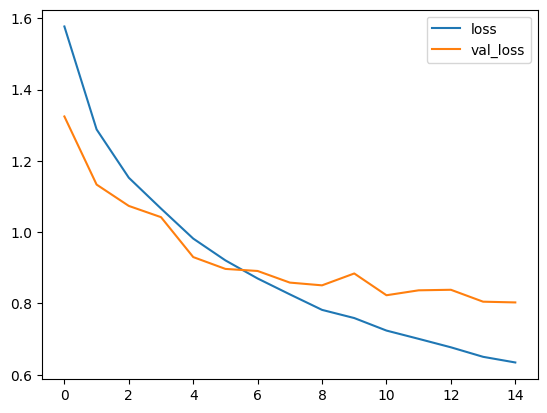

In [5]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()



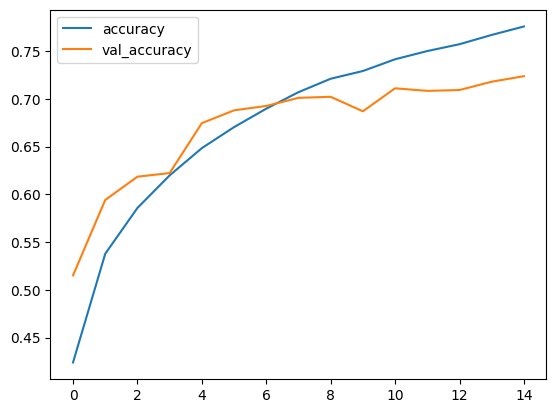

In [6]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_accuracy')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion matrix, without normalization
[[757  19  48  13  14   3  12   9  82  43]
 [ 16 847   4   4   4   1  15   1  22  86]
 [ 67   6 598  55 110  58  59  25  14   8]
 [ 16  11  64 500  92 161  90  34  14  18]
 [ 26   5  61  41 723  31  44  55  11   3]
 [ 14   1  46 194  65 574  46  41   9  10]
 [  9   6  38  39  59  16 813   8   3   9]
 [ 17   1  20  42  55  49  11 780   5  20]
 [ 56  22   6  10   6   5   4   4 854  33]
 [ 41  87   6   9   4   7   9  14  31 792]]


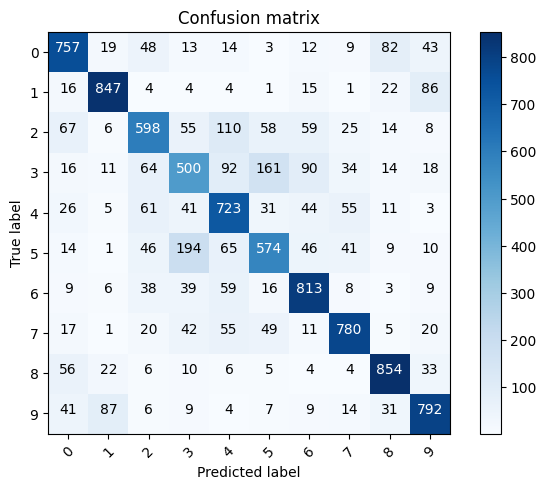

In [7]:
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))
plt.show()

In [8]:
labels = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

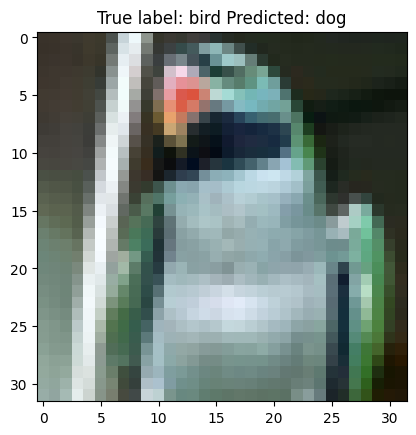

In [9]:
misclassified_idex = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idex)
plt.imshow(x_test[i], cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));